##**Importing Libraries**

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

##**Dataset**

**Dataset Preparation**

In [2]:
class LensDataset(Dataset):
    def __init__(self, lenses_dir, nonlenses_dir, transform=None):
        self.lens_files = [os.path.join(lenses_dir, f) for f in os.listdir(lenses_dir) if f.endswith('.npy')]
        self.nonlens_files = [os.path.join(nonlenses_dir, f) for f in os.listdir(nonlenses_dir) if f.endswith('.npy')]

        self.data_files = self.lens_files + self.nonlens_files
        self.labels = [1] * len(self.lens_files) + [0] * len(self.nonlens_files)  # 1 for lens, 0 for non-lens
        self.transform = transform

    def __len__(self):
        return len(self.data_files)

    def __getitem__(self, idx):
        img_path = self.data_files[idx]
        image = np.load(img_path)
        label = self.labels[idx]

        image = torch.tensor(image, dtype=torch.float32)  # Convert to tensor

        if self.transform:
            image = self.transform(image)

        return image, label

**Data Augmentation**

In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5,), (0.5,))
])

**Defining Dataset Paths**

In [4]:
train_lenses = "/content/drive/MyDrive/train_lenses"
train_nonlenses = "/content/drive/MyDrive/train_nonlenses"
test_lenses = "/content/drive/MyDrive/test_lenses"
test_nonlenses = "/content/drive/MyDrive/test_nonlenses"

In [5]:
train_dataset = LensDataset(train_lenses, train_nonlenses, transform=train_transform)
test_dataset = LensDataset(test_lenses, test_nonlenses, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##**Modelling**

**Defining CNN model**

In [6]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze()

**Preparation of CNN model**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
criterion = nn.BCELoss()  # Binary classification loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

**Training the Model**

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 0.1477
Epoch 2/20, Loss: 0.1210
Epoch 3/20, Loss: 0.1110
Epoch 4/20, Loss: 0.1020
Epoch 5/20, Loss: 0.0937
Epoch 6/20, Loss: 0.0875
Epoch 7/20, Loss: 0.0870
Epoch 8/20, Loss: 0.0817
Epoch 9/20, Loss: 0.0795
Epoch 10/20, Loss: 0.0768
Epoch 11/20, Loss: 0.0754
Epoch 12/20, Loss: 0.0731
Epoch 13/20, Loss: 0.0697
Epoch 14/20, Loss: 0.0691
Epoch 15/20, Loss: 0.0704
Epoch 16/20, Loss: 0.0678
Epoch 17/20, Loss: 0.0689
Epoch 18/20, Loss: 0.0660
Epoch 19/20, Loss: 0.0641


**Evaluating the model**

AUC Score: 0.9734


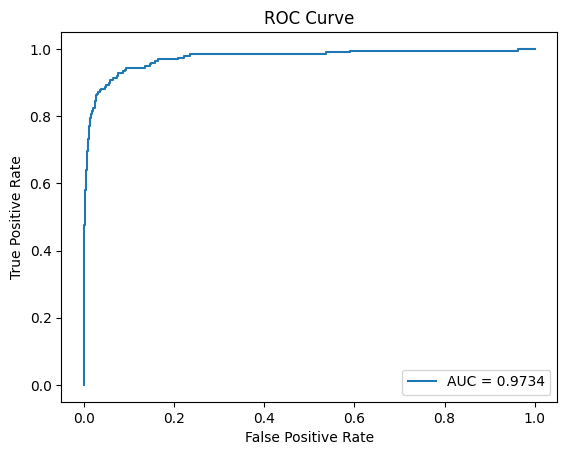

In [10]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).cpu().numpy()
        all_preds.extend(outputs)
        all_labels.extend(labels.numpy())

# Compute AUC Score
auc_score = roc_auc_score(all_labels, all_preds)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_preds)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Saving the model**

In [11]:
# Define the path where the model weights will be saved
model_path = "/content/cnn_weights2.pth"

# Save only the model's state_dict (recommended)
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to {model_path}")

Model weights saved to /content/cnn_weights2.pth
